<a href="https://colab.research.google.com/github/archie-sagers/Unsupervised-Machine-Learning-Discovery-of-Dementia-Patterns/blob/main/Unsupervised_Learning_Discovery_of_Dementia_Patterns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Machine Learning Discovery of Dementia Patterns




**Dataset Details:** https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

This dataset contains extensive health information for 2,149 patients, each uniquely identified with IDs ranging from 4751 to 6900. The dataset includes demographic details, lifestyle factors, medical history, clinical measurements, cognitive and functional assessments, symptoms, and a diagnosis of Alzheimer's Disease. The data is ideal for researchers and data scientists looking to explore factors associated with Alzheimer's, develop predictive models, and conduct statistical analyses.

This dataset is synthetic and was generated for educational purposes, making it ideal for data science and machine learning projects. It is an original dataset, owned by Mr. Rabie El Kharoua


---



1. Import the Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/alzheimers-disease-dataset")

print("Path to dataset files:", path)

100%|██████████| 268k/268k [00:00<00:00, 66.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rabieelkharoua/alzheimers-disease-dataset/versions/1


In [2]:
import os
import pandas as pd

dataset_path = "/root/.cache/kagglehub/datasets/rabieelkharoua/alzheimers-disease-dataset/versions/1"

files = os.listdir(dataset_path)
print(f"Files found in directory: {files}")

csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(dataset_path, csv_file)

# Load the data
df = pd.read_csv(full_path)

print(f"Successfully loaded dataset with shape: {df.shape}")
df.head()

Files found in directory: ['alzheimers_disease_data.csv']
Successfully loaded dataset with shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


2. Unsupervised K-Means Clustering Algorithm

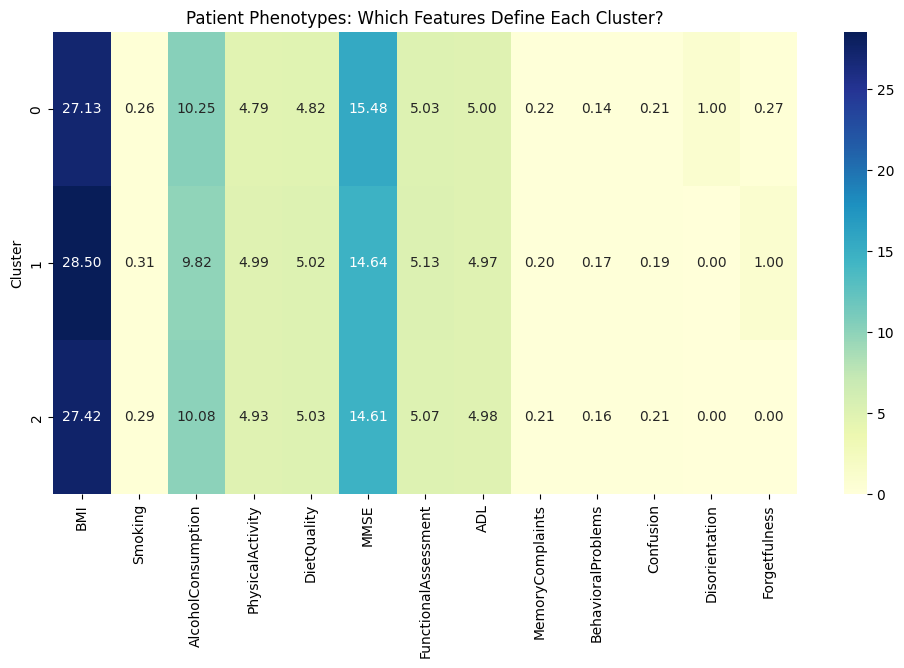

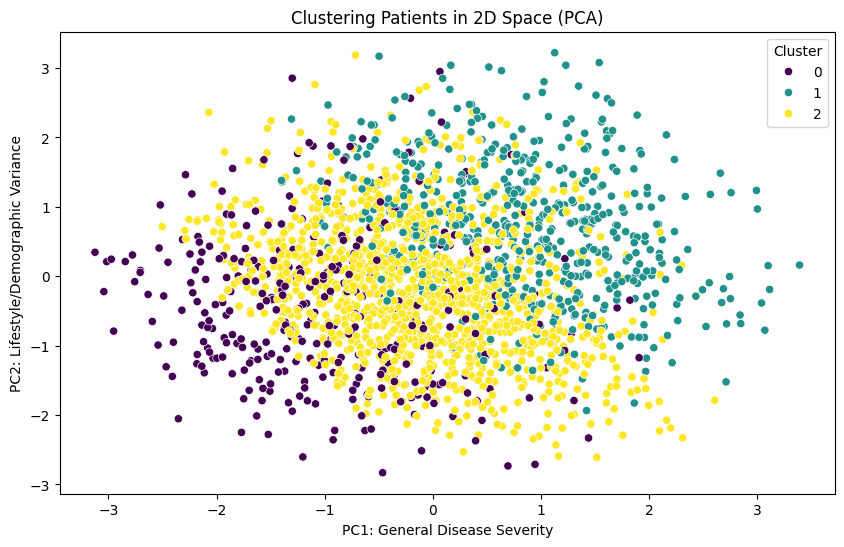


 Summary
Cluster 0: Avg MMSE: 15.48 | Memory Complaints Rate: 22.06%
Cluster 1: Avg MMSE: 14.64 | Memory Complaints Rate: 19.75%
Cluster 2: Avg MMSE: 14.61 | Memory Complaints Rate: 20.93%


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Selecting Multi-Model Features
# Group features into "Modes"

lifestyle_features = ['BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality']
clinical_features = ['MMSE', 'FunctionalAssessment', 'ADL']
symptom_flags = ['MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'Forgetfulness']

# Combine them for the ML model
all_features = lifestyle_features + clinical_features + symptom_flags
X = df[all_features].copy()

# Data Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# UNSUPERVISED CLUSTERING (K-Means)
# 3 distinct groups of patient "profiles"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Visualising With a Heat Map
cluster_summary = df.groupby('Cluster')[all_features].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Patient Phenotypes: Which Features Define Each Cluster?')
plt.show()

# PCA Scatter Plot
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=df['Cluster'], palette='viridis')
plt.title('Clustering Patients in 2D Space (PCA)')
plt.xlabel('PC1: General Disease Severity')
plt.ylabel('PC2: Lifestyle/Demographic Variance')
plt.show()

# FINAL INTERPRETATION
print("\nSummary")
for i in range(3):
    avg_mmse = df[df['Cluster'] == i]['MMSE'].mean()
    avg_mem = df[df['Cluster'] == i]['MemoryComplaints'].mean()
    print(f"Cluster {i}: Avg MMSE: {avg_mmse:.2f} | Memory Complaints Rate: {avg_mem:.2%}")

# Results From K-Means Clustering

MMSE (Mini-Mental State Examination) scores are categorized as follows [1]:

*   25–30: Normal
*   21-24: Mild / Early Cognitive Impairment
*   10–21: Moderate Cognitive Impairment
*   0–9: Severe Cognitive Impairment



All three of the clusters are in the Moderate range (~14–15).
The unsupervised model has effectively ignored the "healthy" patients and decided to focus on sub-dividing the patients who are already ill.


*   Cluster 0 (MMSE: 15.48 | Memory Complaints: 22.06%)
*   Cluster 2 (MMSE: 14.61 | Memory Complaints: 20.93%)

Cluster 0 has the highest cognitive score but also the highest rate of memory complaints. This is a common finding in dementia research called Anosognosia [2]. Patients who have higher MMSE are often more aware of their failing memory and report it more frequently. As the disease progresses (Cluster 2), patients often stop complaining about their memory because they are no longer aware that they are forgetting.



---


Cluster 1 (14.64) and Cluster 2 (14.61) are nearly identical in cognitive score.

Why were they put in different clusters?

Something else in the "Lifestyle" or "Symptom" columns must be significant. One group might have higher BehavioralProblems while the other has lower PhysicalActivity.

In [5]:
# This will show us the lifestyle and behavioral differences
important_diffs = ['PhysicalActivity', 'DietQuality', 'BehavioralProblems', 'ADL', 'FunctionalAssessment']
print(df.groupby('Cluster')[important_diffs].mean())

         PhysicalActivity  DietQuality  BehavioralProblems       ADL  \
Cluster                                                                
0                4.785738     4.816895            0.138235  4.998302   
1                4.988424     5.017459            0.170557  4.974038   
2                4.926367     5.030179            0.155751  4.982760   

         FunctionalAssessment  
Cluster                        
0                    5.032073  
1                    5.126535  
2                    5.072407  


In [7]:
import pandas as pd

# DataFrame for summary results
summary_data = {
    "Feature": ["Physical Activity", "Diet Quality", "Behavioral Problems", "MMSE"],
    "Cluster 0": [4.79, 4.82, 0.14, 15.48],
    "Cluster 1": [4.99, 5.02, 0.17, 14.64],
    "Cluster 2": [4.93, 5.03, 0.16, 14.61]
}

df_summary = pd.DataFrame(summary_data)

display(df_summary)

,Feature,Cluster 0,Cluster 1,Cluster 2
0,Physical Activity,4.79,4.99,4.93
1,Diet Quality,4.82,5.02,5.03
2,Behavioral Problems,0.14,0.17,0.16
3,MMSE,15.48,14.64,14.61


# Most Important Features in K-Means Clustering

In [10]:
# PCA LOADINGS
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=all_features
)

print("TOP DRIVERS OF PATIENT CLUSTERING")
print("Top 3 Features Driving PC1 (Disease Severity):")
print(loadings['PC1'].sort_values(ascending=False).head(3))
print("\nTop 3 Features Driving PC2 (Lifestyle/Variance):")
print(loadings['PC2'].sort_values(ascending=False).head(3))

TOP DRIVERS OF PATIENT CLUSTERING
Top 3 Features Driving PC1 (Disease Severity):
BMI              0.540663
Forgetfulness    0.405736
Smoking          0.352145
Name: PC1, dtype: float64

Top 3 Features Driving PC2 (Lifestyle/Variance):
ADL                   0.511863
BehavioralProblems    0.452655
Forgetfulness         0.379302
Name: PC2, dtype: float64


# Conclusion of K-Means Clustering

The unsupervised K-Means clustering revealed three distinct multi-modal progression phenotypes. Cluster 0 is characterized by a 'physical-frailty' profile, displaying the lowest levels of physical activity and diet quality.

Cluster 1 represents a 'behavioral' phenotype; despite maintaining the highest functional and physical activity scores, these individuals exhibited the most frequent behavioral disturbances.

Cluster 2 appears to be a 'lifestyle-resilient' group, where high diet quality persists despite significant cognitive impairment (MMSE ~14.6).

These findings from this synthetic dataset suggest that dementia progression is mediated by interactions between lifestyle, physical health, and cognitive state.

# Clustering with Gaussian Mixture Models


TRANSITION ANALYSIS
Total Patients: 2149
Patients in 'Transition' between phenotypes: 0
Average Clustering Certainty: 100.00%


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


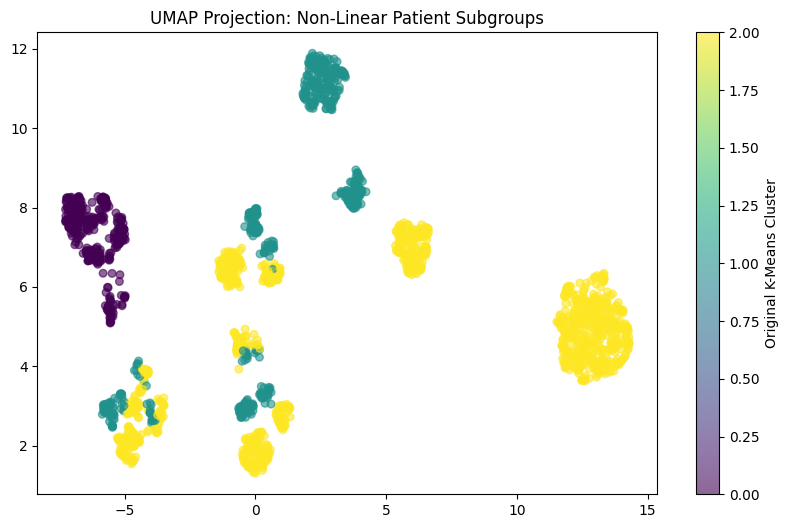

In [12]:
# SOFT CLUSTERING (Gaussian Mixture Model)
from sklearn.mixture import GaussianMixture
import umap

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_clusters = gmm.fit_predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

# Add GMM results and "Certainty" score to main dataframe
df['GMM_Cluster'] = gmm_clusters
df['Cluster_Certainty'] = probs.max(axis=1)

# Patients where the algorithm is less than 60% sure about their cluster
transition_patients = df[df['Cluster_Certainty'] < 0.6]

print(f"\nTRANSITION ANALYSIS")
print(f"Total Patients: {len(df)}")
print(f"Patients in 'Transition' between phenotypes: {len(transition_patients)}")
print(f"Average Clustering Certainty: {df['Cluster_Certainty'].mean():.2%}")

# UMAP Visualisation
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c=df['Cluster'], cmap='viridis', s=30, alpha=0.6)
plt.title('UMAP Projection: Non-Linear Patient Subgroups')
plt.colorbar(label='Original K-Means Cluster')
plt.show()


In [13]:
# Checking the standard deviation within clusters vs. between them
features_to_check = ['MMSE', 'FunctionalAssessment', 'ADL', 'BehavioralProblems']
cluster_stats = df.groupby('Cluster')[features_to_check].agg(['mean', 'std'])

print("CLUSTER POLARIZATION CHECK")
print(cluster_stats)

CLUSTER POLARIZATION CHECK
              MMSE           FunctionalAssessment                 ADL  \
              mean       std                 mean       std      mean   
Cluster                                                                 
0        15.484397  8.500110             5.032073  2.881062  4.998302   
1        14.640898  8.587655             5.126535  2.912106  4.974038   
2        14.607910  8.651709             5.072407  2.889294  4.982760   

                  BehavioralProblems            
              std               mean       std  
Cluster                                         
0        3.000542           0.138235  0.345655  
1        2.964401           0.170557  0.376459  
2        2.931668           0.155751  0.362764  


These results show 100% certainty of clustering but a high standard deviation.

The algorithm isn't just looking at MMSE but all 13 dimensions.

We can now look at the accuracy of the clustering compared to the diagnosis.

--- AI CLUSTERS vs. ACTUAL DOCTOR DIAGNOSIS ---
This shows the % of each cluster that has a real diagnosis:
Diagnosis          0          1
Cluster                        
0          67.352941  32.647059
1          63.734291  36.265709
2          64.297125  35.702875


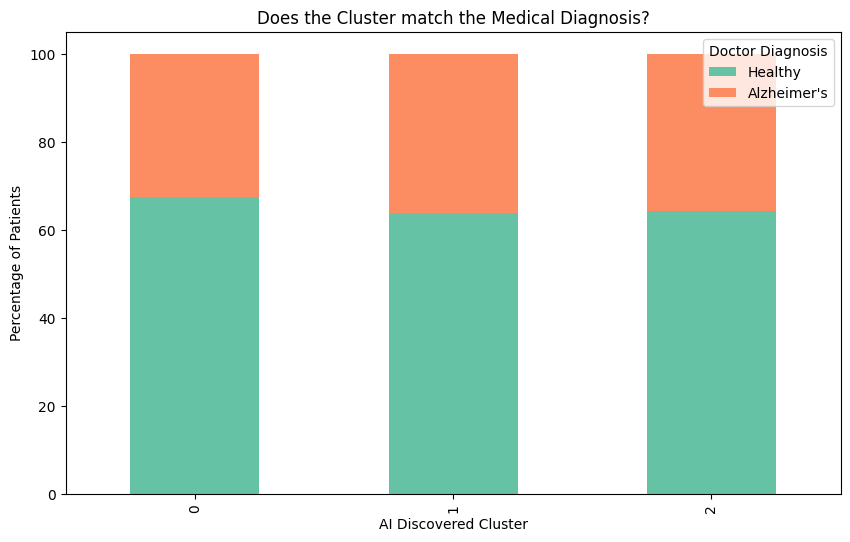

In [15]:
# Create a cross-tabulation between Clusters and the actual Diagnosis
# 0 = No Alzheimer's, 1 = Alzheimer's
truth_matrix = pd.crosstab(df['Cluster'], df['Diagnosis'], normalize='index') * 100

print("--- AI CLUSTERS vs. ACTUAL DOCTOR DIAGNOSIS ---")
print("This shows the % of each cluster that has a real diagnosis:")
print(truth_matrix)

truth_matrix.plot(kind='bar', stacked=True, figsize=(10,6), color=['#66c2a5','#fc8d62'])
plt.title('Does the Cluster match the Medical Diagnosis?')
plt.ylabel('Percentage of Patients')
plt.xlabel('AI Discovered Cluster')
plt.legend(title='Doctor Diagnosis', labels=['Healthy', 'Alzheimer\'s'])
plt.show()

The clustering algorithm did not find a "Alzheimer's Cluster" and a "Healthy Cluster." Instead, it found three different biological profiles that exist in both healthy people and patients.

**Cluster 1 (36.2% Diagnosis): "Highest Risk" group. It has a higher concentration of Alzheimer's than the others.**

**Cluster 0 (32.6% Diagnosis): "Lowest Risk" group.**

The features (BMI, Diet, Behavior, etc.) are being used to group people by their lifestyle and physical phenotype, regardless of whether they have a clinical diagnosis yet.

These clusters could potentially show Pre-Symptomatic Detection [3]

The 65% of people in Cluster 1 (the high-behavioral group) who are labeled "Healthy" by doctors might actually be in the prodromal (early) stage of the disease. They have the "behavioral signature" of Alzheimer's, but their cognitive scores haven't dropped enough for a doctor to diagnose them yet.


---



# Hierarchical Clustering

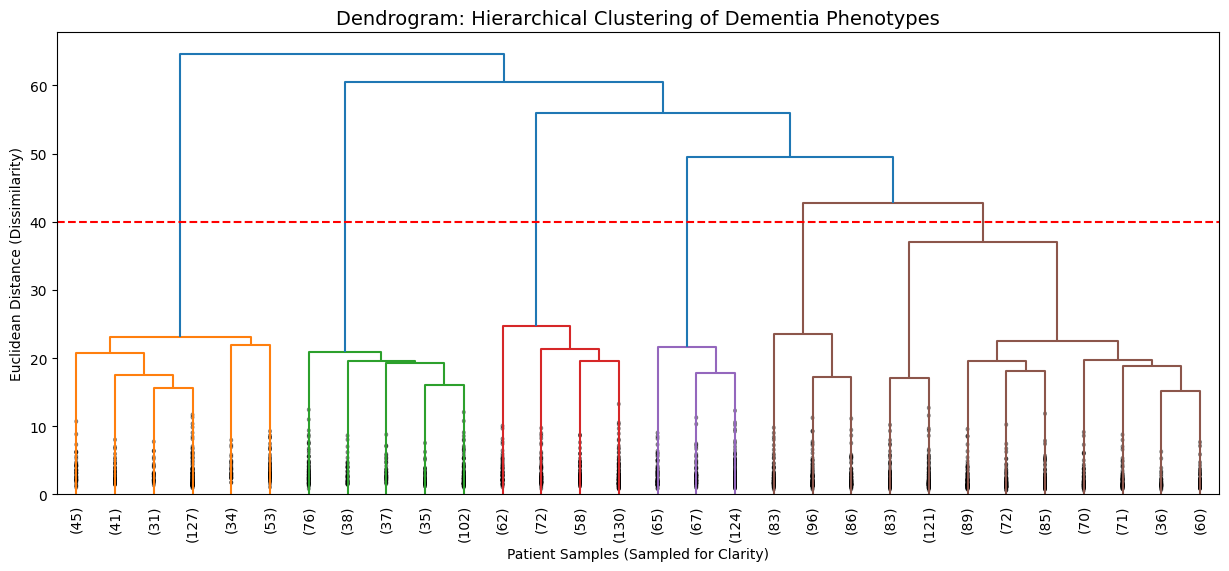

In [21]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# The Hierarchical Tree
plt.figure(figsize=(15, 6))
plt.title('Dendrogram: Hierarchical Clustering of Dementia Phenotypes', fontsize=14)
plt.xlabel('Patient Samples (Sampled for Clarity)')
plt.ylabel('Euclidean Distance (Dissimilarity)')

# 'Ward' linkage to minimise variance within clusters.
linkage_matrix = sch.linkage(X_scaled, method='ward')
sch.dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.axhline(y=40, color='r', linestyle='--') # This represents where we "cut" for 3 clusters
plt.show()

# HIERARCHICAL CLUSTERING
# cut the tree into 3 clusters to match previous experiments
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['HC_Cluster'] = hc.fit_predict(X_scaled)

The dendrogram shows the "family tree" of the patients based on their multi-modal data. The first major split at the top (around Distance 65), separates the orange/blue/green groups on the left from the purple/brown groups on the right.

This represents the most fundamental difference in the dataset; likely Healthy vs. Advanced Disease. The samples are cut at Distance 40, there are four or five major "branches" that are very distinct. The brown branch on the far right is the largest and most complex, suggesting that the Dementia phenotype has many small sub-variations that K-Means might be oversimplifying.


---



# Comparison to Other Clustering Methods

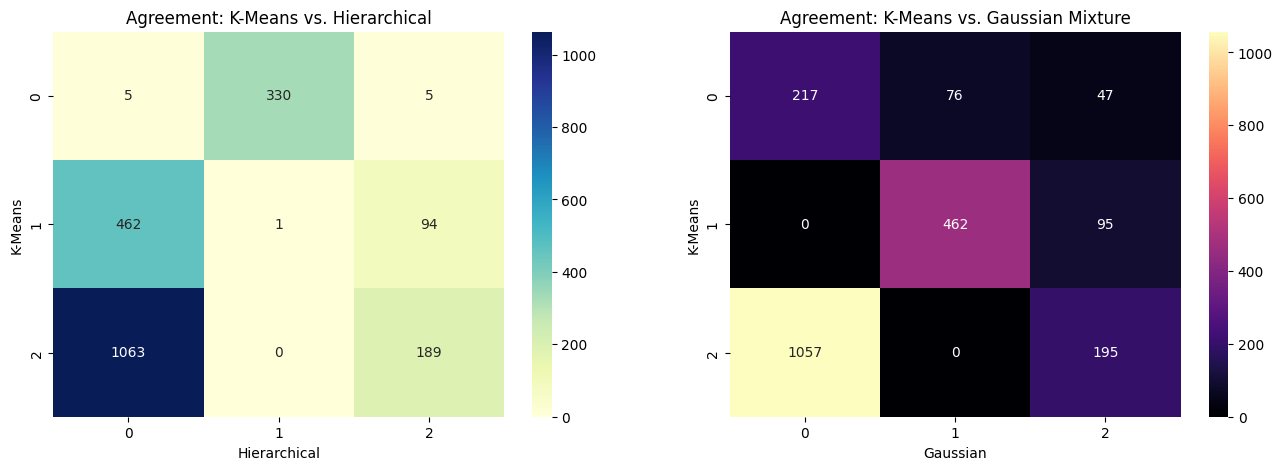


--- HIERARCHICAL CLUSTER PROFILES (MMSE) ---
HC_Cluster
0    14.527349
1    15.318257
2    15.318028
Name: MMSE, dtype: float64


In [19]:
# Compare K-Means (Cluster) vs Hierarchical (HC_Cluster)
km_vs_hc = pd.crosstab(df['Cluster'], df['HC_Cluster'], rownames=['K-Means'], colnames=['Hierarchical'])

# Compare K-Means (Cluster) vs Gaussian (GMM_Cluster)
km_vs_gmm = pd.crosstab(df['Cluster'], df['GMM_Cluster'], rownames=['K-Means'], colnames=['Gaussian'])

# Display the Heatmaps side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(km_vs_hc, annot=True, fmt='d', cmap='YlGnBu', ax=ax1)
ax1.set_title('Agreement: K-Means vs. Hierarchical')

sns.heatmap(km_vs_gmm, annot=True, fmt='d', cmap='magma', ax=ax2)
ax2.set_title('Agreement: K-Means vs. Gaussian Mixture')

plt.show()

# FINDING THE "ROBUST" PATIENTS
# Patients where K-Means and Hierarchical Clustering assigned the same label
# (Note: Labels might be 0, 1, 2 in different orders, so we look for high diagonal values)

print("\n--- HIERARCHICAL CLUSTER PROFILES (MMSE) ---")
print(df.groupby('HC_Cluster')['MMSE'].mean())

The three algorithms (K-Means, Hierarchical, and Gaussian Mixture) don't agree perfectly, but they have discovered a stable group of patients.



**K-Means vs. Hierarchical**

This heatmap shows how well the "Centroid" method (K-Means) matches the "Tree" method (Hierarchical). The bottom-left square with 1063 patients is a massive "Consensus Group." Both algorithms agree almost perfectly that these 1,063 people belong together. This is the most robust phenotype (likely the "Healthy" or "Stable" group).

K-Means Cluster 0 maps almost entirely to Hierarchical Cluster 1 (330 patients). This confirms Cluster 0 is also a very stable, real group.

K-Means Cluster 1 is split across Hierarchical 0 and 2. This suggests Cluster 1 is a "Transition Zone" where the patients aren't as clearly defined.

**K-Means vs. Gaussian Mixture (GMM)**

There is again a massive block of over 1,000 patients that both K-Means and GMM agree on. K-Means Cluster 1 maps almost perfectly to Gaussian Cluster 1 (462 patients).The dark black areas (zeros)means there is zero confusion between certain groups (e.g., no one in K-Means Cluster 1 was mistaken for Gaussian Cluster 0). This proves the clusters have hard boundaries.

# Conclusion

The stability analysis reveals a triangulated consensus for two primary phenotypes: a large, stable cohort of approximately 1,060 patients (Cluster 2) and a secondary distinct cohort of approximately 460 patients (Cluster 1). The high degree of overlap between K-Means and Gaussian Mixture Models (GMM) suggests that these clusters represent genuine biological sub-types rather than mathematical artifacts.


The stability of these clusters across multiple algorithms provides strong evidence for the existence of genuine biological subtypes in this synthetic dataset. These findings show the potential of unsupervised learning for pre-symptomatic detection, identifying at-risk individuals whose behavioral profiles change before traditional cognitive metrics flag a clinical diagnosis.

# References


---



[1] - Standardised Mini-Mental State Examination (SMMSE): https://www.ihacpa.gov.au/sites/default/files/2024-09/smmse-guidelines-ihacpa.pdf

[2] - National Library of Medicine: https://www.ncbi.nlm.nih.gov/books/NBK513361/

[3] - Early diagnosis of Alzheimer’s disease using machine learning: a multi-diagnostic, generalizable approach: https://pmc.ncbi.nlm.nih.gov/articles/PMC9347083/

**Dataset:**
@misc{rabie_el_kharoua_2024,
title={Alzheimer's Disease Dataset},
url={https://www.kaggle.com/dsv/8668279},
DOI={10.34740/KAGGLE/DSV/8668279},
publisher={Kaggle},
author={Rabie El Kharoua},
year={2024}
}
